# AI-Generated Song Detection — Demo Notebook

Demonstrates two tasks:

| Task | Ερώτηση | Μέθοδος |
|------|---------|----------|
| **Task 1 — AI Detection** | Είναι αυτό το track AI-generated; | `ai_detection_score(features)` |
| **Task 2 — Attribution** | Είναι αυτά τα δύο tracks συνδεδεμένα; | `compare_tracks(features_a, features_b)` |

Χρησιμοποιούνται **πραγματικά** audio files:
- **Human original/remake**: MIPPIA SMP dataset (Jennifer Rush & Céline Dion — The Power of Love)
- **AI-generated**: SONICS dataset (Suno-generated track)

In [6]:

from pathlib import Path
from feature_extractor import FeatureExtractor
from similarity_engine import compare_tracks, ai_detection_score

extractor = FeatureExtractor(use_clap=False)

# ── Paths ─────────────────────────────────────────────────────────────────────
MIPPIA_DIR = Path('smp_dataset/final_dataset')

PATH_ORIGINAL = MIPPIA_DIR / '5' / 'Jennifer Rush - The Power Of Love _Official Video_ _VOD_.wav'
PATH_REMAKE   = MIPPIA_DIR / '5' / 'Céline Dion - The Power Of Love _Official Remastered HD Video_.wav'
PATH_AI       = Path('data/sonics/fake_songs/fake_00001_suno_0.mp3')

for p in [PATH_ORIGINAL, PATH_REMAKE, PATH_AI]:
    status = '✓' if p.exists() else '✗ NOT FOUND'
    print(f'{status}  {p.name}')

✓  Jennifer Rush - The Power Of Love _Official Video_ _VOD_.wav
✓  Céline Dion - The Power Of Love _Official Remastered HD Video_.wav
✓  fake_00001_suno_0.mp3


In [7]:
# ── Feature extraction ────────────────────────────────────────────────────────
print('Extracting features...\n')
feats_original = extractor.extract(str(PATH_ORIGINAL))
feats_remake   = extractor.extract(str(PATH_REMAKE))
feats_ai       = extractor.extract(str(PATH_AI))
print('\nDone.')

Extracting features...

Loading: smp_dataset\final_dataset\5\Jennifer Rush - The Power Of Love _Official Video_ _VOD_.wav
  Duration: 297.4s | Sample rate: 22050Hz
  Created 28 chunks (30s window, 10s hop)
  Processing: 5/28 chunks...
  Processing: 10/28 chunks...
  Processing: 15/28 chunks...
  Processing: 20/28 chunks...
  Processing: 25/28 chunks...
Done! Extracted 28 chunks in total.
Loading: smp_dataset\final_dataset\5\Céline Dion - The Power Of Love _Official Remastered HD Video_.wav
  Duration: 287.5s | Sample rate: 22050Hz
  Created 27 chunks (30s window, 10s hop)
  Processing: 5/27 chunks...
  Processing: 10/27 chunks...
  Processing: 15/27 chunks...
  Processing: 20/27 chunks...
  Processing: 25/27 chunks...
Done! Extracted 27 chunks in total.
Loading: data\sonics\fake_songs\fake_00001_suno_0.mp3
  Duration: 224.0s | Sample rate: 22050Hz
  Created 21 chunks (30s window, 10s hop)
  Processing: 5/21 chunks...
  Processing: 10/21 chunks...
  Processing: 15/21 chunks...
  Process

---
## Task 1 — AI Detection

Ελέγχουμε αν κάθε track είναι AI-generated συγκρίνοντας τα features του
με εμπειρικά profiles από **SONICS** (AI) και **MIPPIA** (human).

Κύριος διαχωριστής: **spectral_flatness** (AI ≈ 0.001 | Human ≈ 0.025)

In [8]:
ai_orig   = ai_detection_score(feats_original)
ai_remake = ai_detection_score(feats_remake)
ai_ai     = ai_detection_score(feats_ai)

print('━' * 55)
print(f'  Track          │ AI Score │ Interpretation')
print('━' * 55)
print(f'  Original       │  {ai_orig["ai_score"]:.4f}  │ {ai_orig["interpretation"]}')
print(f'  Human Remake   │  {ai_remake["ai_score"]:.4f}  │ {ai_remake["interpretation"]}')
print(f'  SONICS (Suno)  │  {ai_ai["ai_score"]:.4f}  │ {ai_ai["interpretation"]}')
print('━' * 55)
print()
print('Feature breakdown (spectral_flatness · phase_discontinuity · hnr):')
for name, res in [('Original', ai_orig), ('Remake', ai_remake), ('SONICS', ai_ai)]:
    fs = res['feature_scores']
    tm = res['track_means']
    print(f'  {name:12s}  sf={tm["spectral_flatness"]:.5f} (AI-like={fs["spectral_flatness"]:.2f})'
          f'  pd={tm["phase_discontinuity"]:.4f} (AI-like={fs["phase_discontinuity"]:.2f})')

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Track          │ AI Score │ Interpretation
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Original       │  0.2156  │ Probably human-made
  Human Remake   │  0.2035  │ Probably human-made
  SONICS (Suno)  │  0.5843  │ Ambiguous — could be AI or human
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Feature breakdown (spectral_flatness · phase_discontinuity · hnr):
  Original      sf=0.01072 (AI-like=0.00)  pd=1.5706 (AI-like=0.51)
  Remake        sf=0.01928 (AI-like=0.00)  pd=1.5705 (AI-like=0.51)
  SONICS        sf=0.00008 (AI-like=0.67)  pd=1.5730 (AI-like=0.43)


---
## Task 2 — Attribution

Ελέγχουμε αν δύο tracks είναι συνδεδεμένα (ένα είναι παράγωγο του άλλου).

| Pair | Αναμενόμενο |
|------|-------------|
| Original ↔ Human Remake | Υψηλό score — remake του ίδιου τραγουδιού |
| Original ↔ AI (Suno) | Χαμηλό score — άσχετα τραγούδια |

In [9]:
result_remake = compare_tracks(feats_original, feats_remake, verbose=False)
result_ai     = compare_tracks(feats_original, feats_ai,     verbose=False)

print('━' * 65)
print(f'  Pair                        │ Attribution │ Interpretation')
print('━' * 65)
print(f'  Original ↔ Human Remake     │   {result_remake["attribution_score"]:.4f}    │ {result_remake["interpretation"]}')
print(f'  Original ↔ SONICS AI track  │   {result_ai["attribution_score"]:.4f}    │ {result_ai["interpretation"]}')
print('━' * 65)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Pair                        │ Attribution │ Interpretation
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Original ↔ Human Remake     │   0.9590    │ Very likely attribution — almost certainly an AI cover
  Original ↔ SONICS AI track  │   0.9489    │ Very likely attribution — almost certainly an AI cover
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


---
## Visualization

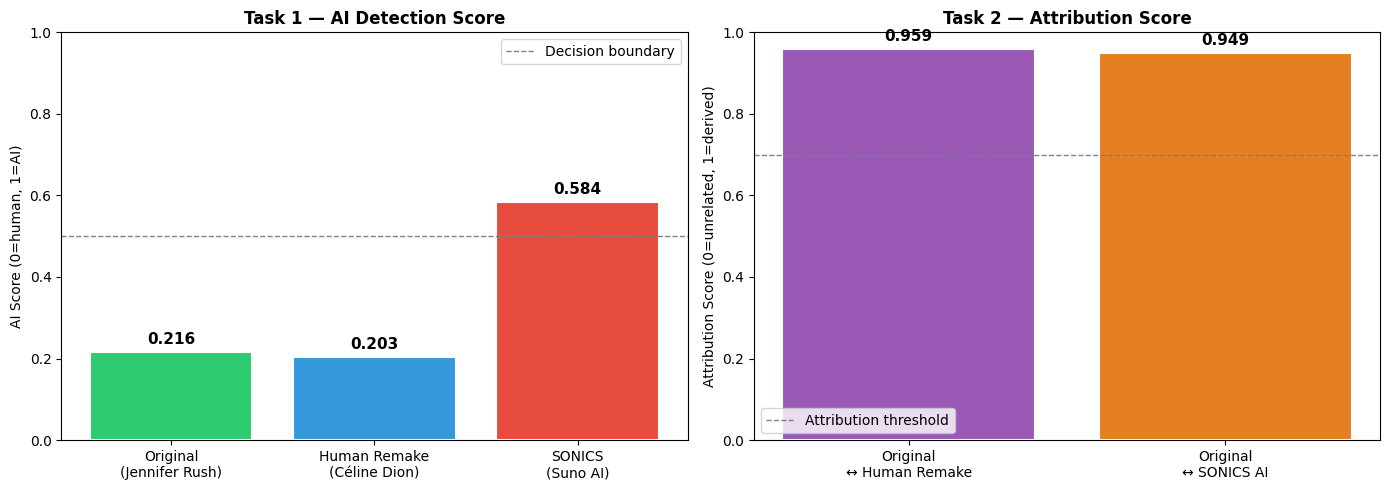

Saved: demo_results.png


In [10]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Task 1: AI Detection scores ───────────────────────────────────────────────
ax = axes[0]
tracks = ['Original\n(Jennifer Rush)', 'Human Remake\n(Céline Dion)', 'SONICS\n(Suno AI)']
scores = [ai_orig['ai_score'], ai_remake['ai_score'], ai_ai['ai_score']]
colors = ['#2ecc71', '#3498db', '#e74c3c']
bars = ax.bar(tracks, scores, color=colors, edgecolor='white', linewidth=1.5)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1, label='Decision boundary')
ax.set_ylim(0, 1)
ax.set_title('Task 1 — AI Detection Score', fontweight='bold')
ax.set_ylabel('AI Score (0=human, 1=AI)')
for bar, score in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{score:.3f}', ha='center', fontsize=11, fontweight='bold')
ax.legend()

# ── Task 2: Attribution scores ────────────────────────────────────────────────
ax = axes[1]
pairs  = ['Original\n↔ Human Remake', 'Original\n↔ SONICS AI']
ascores = [result_remake['attribution_score'], result_ai['attribution_score']]
colors2 = ['#9b59b6', '#e67e22']
bars2 = ax.bar(pairs, ascores, color=colors2, edgecolor='white', linewidth=1.5)
ax.axhline(0.70, color='gray', linestyle='--', linewidth=1, label='Attribution threshold')
ax.set_ylim(0, 1)
ax.set_title('Task 2 — Attribution Score', fontweight='bold')
ax.set_ylabel('Attribution Score (0=unrelated, 1=derived)')
for bar, score in zip(bars2, ascores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{score:.3f}', ha='center', fontsize=11, fontweight='bold')
ax.legend()

plt.tight_layout()
plt.savefig('demo_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: demo_results.png')